# COMP8325 — Task 1: Malware category classification (BODMAS)

This notebook loads LIEF/Ember-style features from `bodmas.npz`, aligns rows with `bodmas_metadata.csv`, and assigns **malware category** labels from `bodmas_malware_category.csv` (not malware *family* from metadata). Benign samples (`y=0` in the npz) are labelled **benign**.

**Models compared:** (1) Random Forest, (2) Histogram-based Gradient Boosting (`HistGradientBoostingClassifier`).

**Metrics:** overall accuracy; per-class TPR (recall) and FPR (one-vs-rest), including benign.

**Runtime:** with `QUICK_MODE = False`, hyperparameter search on this dataset can take many hours. Use `QUICK_MODE = True` only to verify the pipeline; set `QUICK_MODE = False` for the results you report.

### Mapping to the Task 1 rubric (checklist)

| Rubric area | Where addressed in this notebook |
|-------------|----------------------------------|
| Data loading & labels | §2 |
| Preprocessing & features | §4 (imputation + variance filter; train-fit only) |
| Train/test split | §3 (stratified hold-out) |
| Hyperparameter tuning | §6 subsample + adaptive CV (`StratifiedKFold` 2–3 splits, or `StratifiedShuffleSplit` if a class is too small) + §8–9 `RandomizedSearchCV` (`f1_macro`) |
| Evaluation (accuracy, TPR, FPR per class) | §5 helpers; §11 tables; §10 confusion matrices (figures for PDF) |
| Algorithm discussion (report) | §7 outline → expand with citations in PDF |
| Reproducibility | §1 (`RANDOM_STATE`, versions, `requirements.txt`; artifacts saved in §11) |


## 1. Configuration and imports


In [20]:
from __future__ import annotations
import json
import sys
from pathlib import Path
from types import SimpleNamespace
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, StratifiedShuffleSplit, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import sklearn

# Paths
DATA_DIR = Path("data")
NPZ_PATH = DATA_DIR / "bodmas.npz"
META_PATH = DATA_DIR / "bodmas_metadata.csv"
CAT_PATH = DATA_DIR / "bodmas_malware_category.csv"

# Hyperparameters & Reproducibility
RANDOM_STATE = 42
TEST_SIZE = 0.2
TUNE_SUBSAMPLE_FRACTION = 0.25
QUICK_MODE = False

print(f"Python: {sys.version.split()[0]} | scikit-learn: {sklearn.__version__}")

Python: 3.13.9 | scikit-learn: 1.7.2


## 2. Load features and build multiclass labels


In [21]:
raw = np.load(NPZ_PATH)
X = raw["X"]
y_binary = raw["y"]

meta = pd.read_csv(META_PATH)
cats = pd.read_csv(CAT_PATH)

# Align rows
meta = meta.rename(columns={"sha": "sha256"})
merged = meta.merge(cats, on="sha256", how="left")

# Assign labels: if y=0 -> benign, else use category
y_category = np.where(y_binary == 0, "benign", merged["category"].astype(str).values)

print(f"X shape: {X.shape}")
print("Class counts:\n", pd.Series(y_category).value_counts())

X shape: (134435, 2381)
Class counts:
 benign                77142
trojan                29972
worm                  16697
backdoor               7331
downloader             1031
ransomware              821
dropper                 715
informationstealer      448
virus                   192
pua                      29
cryptominer              20
p2p-worm                 16
exploit                  12
trojan-gamethief          6
rootkit                   3
Name: count, dtype: int64


## 3. Encode labels and stratified train/test split


In [22]:
le = LabelEncoder()
y = le.fit_transform(y_category)
class_names = le.classes_.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

## 4. Feature preprocessing (train-fit only)

LIEF/Ember-like vectors are numeric tabular features (histograms, counts, imports). We:

1. Cast to `float64` for stable numerics.
2. Report NaN/Inf counts **before** fixing them (expected to be rare).
3. **`SimpleImputer(strategy="median")`** — statistics computed **only on `X_train`**, then applied to train and test (no leakage).
4. **`VarianceThreshold(0)`** — drops columns with **zero variance on the training set** (uninformative constants). Fit on train only; same columns dropped on test.

**Scaling:** not applied. Tree ensembles split on thresholds and are largely **invariant to monotone transforms** of individual features; distance-based scaling would matter for e.g. SVM/k-NN, which we do not use here.

*Expand these choices and any trade-offs in your PDF (rubric: preprocessing & feature handling).*

In [23]:
def safe_preprocess(X_train_raw, X_test_raw):
    # 1. Imputation
    imputer = SimpleImputer(strategy="median")
    X_train_imputed = imputer.fit_transform(X_train_raw)
    X_test_imputed = imputer.transform(X_test_raw)
    
    # 2. Variance Filter (Remove constant features)
    selector = VarianceThreshold(threshold=0.0)
    X_train_proc = selector.fit_transform(X_train_imputed)
    X_test_proc = selector.transform(X_test_imputed)
    
    return X_train_proc, X_test_proc, imputer, selector

X_train, X_test, imputer, variance_selector = safe_preprocess(X_train, X_test)
print(f"Features reduced: {X.shape[1]} -> {X_train.shape[1]}")

Features reduced: 2381 -> 2331


## 5. Per-class TPR / FPR helpers


In [24]:
def per_class_tpr_fpr(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tpr, fpr = [], []
    n = cm.sum()
    for k in range(len(labels)):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = n - tp - fn - fp
        tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)
    return np.array(tpr), np.array(fpr)

## 6. Tuning subsample (training data only)


In [27]:
def stratified_subsample_indices(
    y_array: np.ndarray,
    fraction: float,
    seed: int,
    min_per_class: int = 3,
) -> np.ndarray:
    """Stratified subsample so rare classes keep enough rows for k-fold CV."""
    if fraction >= 1.0:
        return np.arange(len(y_array))
    rng = np.random.default_rng(seed)
    idx = []
    for c in np.unique(y_array):
        c_idx = np.flatnonzero(y_array == c)
        n_frac = int(np.ceil(len(c_idx) * fraction))
        n_take = min(len(c_idx), max(n_frac, min(min_per_class, len(c_idx))))
        idx.append(rng.choice(c_idx, size=n_take, replace=False))
    return np.concatenate(idx)


tune_idx = stratified_subsample_indices(y_train, TUNE_SUBSAMPLE_FRACTION, TUNE_RANDOM_STATE)
X_tune = X_train[tune_idx]
y_tune = y_train[tune_idx]

counts_tune = np.bincount(y_tune, minlength=len(class_names))
min_class_tune = int(counts_tune.min())

# StratifiedKFold needs at least n_splits samples per class in y_tune.
if min_class_tune >= 3:
    cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
elif min_class_tune == 2:
    cv_tuning = StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
else:
    cv_tuning = StratifiedShuffleSplit(
        n_splits=5,
        test_size=0.25,
        random_state=RANDOM_STATE,
    )
    print(
        "Note: rarest class in tuning set has only",
        min_class_tune,
        "sample(s); using StratifiedShuffleSplit(5) instead of KFold (document in report).",
    )

print(
    "Tuning set size:",
    X_tune.shape[0],
    "(fraction of train:",
    TUNE_SUBSAMPLE_FRACTION,
    ") | CV:",
    cv_tuning,
    "| min class count in tune:",
    min_class_tune,
)

Tuning set size: 26897 (fraction of train: 0.25 ) | CV: StratifiedKFold(n_splits=2, random_state=42, shuffle=True) | min class count in tune: 2


## 7. Algorithm choice — draft bullets for the PDF *discussion* (rubric: 3 marks)

Use peer-reviewed or technical references in your report (Ember/malware ML surveys). Below is a starting outline.

**Random Forest:** ensemble of bagged trees; reduces variance; robust to noise and irrelevant features; **parallel** training; `class_weight` mitigates imbalance; interpretability via impurity-based feature importance (cite cautiously—biased toward high-cardinality features).

**Histogram Gradient Boosting:** **sequential** boosting on weak learners; often strong accuracy on tabular data; native histogram binning is efficient on large \(n\) × high \(p\); typically more sensitive to hyperparameters than RF.

**Why compare these two:** both handle multiclass tabular features without explicit scaling, enabling a fair comparison of **bagging vs boosting** under the same preprocessing and evaluation protocol.

**Alternatives you might mention as *not* chosen:** linear models (assume linear boundaries), kernel SVM (costly at \(n \approx 10^5\)), deep nets (sample size vs parameter count, less interpretable for this coursework).

Replace this cell’s bullets with your own cited prose in the report; keep the notebook readable as a roadmap.

## 8. Model A — Random Forest

Random Forest is often the **slow** step here. Speed controls (see §1): **`max_samples`**, **`max_leaf_nodes`**, **`RF_FIT_TRAIN_ROWS`** (stratified subset used only for `.fit`; train/test metrics still run on the **full** splits), and **`RF_SEARCH_N_ITER`**. Set `RF_FIT_TRAIN_ROWS = None` only if you can wait for a full-data fit.


In [28]:
# Defaults if §1 was not re-run after updating the notebook (avoids NameError).
if "RF_MAX_SAMPLES" not in globals():
    RF_MAX_SAMPLES = 0.20
if "RF_SEARCH_N_ITER" not in globals():
    RF_SEARCH_N_ITER = 4
if "RF_MAX_LEAF_NODES" not in globals():
    RF_MAX_LEAF_NODES = 384
if "RF_FIT_TRAIN_ROWS" not in globals():
    RF_FIT_TRAIN_ROWS = 30_000

rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=RF_MAX_SAMPLES,
    max_leaf_nodes=RF_MAX_LEAF_NODES,
)

rf_param_dist = {
    "n_estimators": [64, 100, 128],
    "max_depth": [20, 24, 28],
    "min_samples_leaf": [2, 4],
    "max_features": ["sqrt", 0.25],
}

rf_search = RandomizedSearchCV(
    rf_base,
    rf_param_dist,
    n_iter=RF_SEARCH_N_ITER,
    scoring="f1_macro",
    cv=cv_tuning,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

rf_search.fit(X_tune, y_tune)
print("Best RF params:", rf_search.best_params_)
print("Best CV f1_macro:", rf_search.best_score_)

rf_model = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_samples=RF_MAX_SAMPLES,
    max_leaf_nodes=RF_MAX_LEAF_NODES,
)

_fit_cap = RF_FIT_TRAIN_ROWS
if _fit_cap is not None and len(X_train) > _fit_cap:
    _sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=_fit_cap,
        random_state=RANDOM_STATE,
    )
    _tr_idx, _ = next(_sss.split(X_train, y_train))
    X_rf_fit, y_rf_fit = X_train[_tr_idx], y_train[_tr_idx]
    print(
        "Random Forest fit: stratified train subset",
        len(y_rf_fit),
        "rows (full train",
        len(y_train),
        "); train metrics below use full train split.",
    )
else:
    X_rf_fit, y_rf_fit = X_train, y_train

rf_model.fit(X_rf_fit, y_rf_fit)
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_acc, rf_train_df = metrics_report(
    "Random Forest (train)", y_train, rf_train_pred, class_names
)
rf_test_acc, rf_test_df = metrics_report(
    "Random Forest (test)", y_test, rf_test_pred, class_names
)

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Best RF params: {'n_estimators': 64, 'min_samples_leaf': 2, 'max_features': 0.25, 'max_depth': 28}
Best CV f1_macro: 0.433863696963795
Random Forest fit: stratified train subset 30000 rows (full train 107548 ); train metrics below use full train split.

=== Random Forest (train) ===
Overall accuracy: 0.9591
             class  TPR (recall)      FPR
          backdoor      0.946633 0.004180
            benign      0.996678 0.025592
       cryptominer      0.000000 0.000000
        downloader      0.482424 0.000300
           dropper      0.536713 0.000383
           exploit      0.300000 0.000000
informationstealer      0.653631 0.000168
          p2p-worm      0.000000 0.000000
               pua      0.000000 0.000000
        ransomware      0.821918 0.001095
           rootkit      0.000000 0.000000
            trojan      0.909080 0.019708
  trojan-gamethief      0.000000 0.000000
             virus      0.352941 0.000019
  

## 9. Model B — Histogram Gradient Boosting

`HistGradientBoostingClassifier` uses **`early_stopping=False`** (avoids an internal stratified val split that breaks when a rare class has count 1 inside a CV fold).

**Speed / optimisation (see §1):** `HGB_SEARCH_N_ITER`, tighter grids (bounded `max_depth`, lower `max_iter`), **`max_bins=HGB_MAX_BINS`** (fewer histogram bins → faster), and **`HGB_FIT_TRAIN_ROWS`** (stratified subset for `.fit` only; metrics still use full train/test). Set `HGB_FIT_TRAIN_ROWS = None` for a full-data final fit.


In [ ]:
## 9. Model B — Histogram Gradient Boosting

from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import HalvingRandomSearchCV, StratifiedShuffleSplit

if "HGB_SEARCH_N_ITER" not in globals():
    HGB_SEARCH_N_ITER = 8
if "HGB_MAX_BINS" not in globals():
    HGB_MAX_BINS = 64
if "HGB_FIT_TRAIN_ROWS" not in globals():
    HGB_FIT_TRAIN_ROWS = 35_000

hgb_param_dist = {
    "learning_rate": [0.05, 0.08, 0.12],
    "max_leaf_nodes": [31, 63],
    "min_samples_leaf": [20, 30, 50],
    "l2_regularization": [0.0, 0.1, 1.0],
    "max_iter": [150, 250],
    "max_features": [0.8, 1.0],
    "max_depth": [None, 10, 14],
}

hgb_base = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_bins=HGB_MAX_BINS,
)

hgb_search = HalvingRandomSearchCV(
    estimator=hgb_base,
    param_distributions=hgb_param_dist,
    n_candidates=HGB_SEARCH_N_ITER,
    scoring="f1_macro",
    cv=cv_tuning,           # from step 6
    factor=3,
    resource="max_iter",
    max_resources=250,
    min_resources=60,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

hgb_search.fit(X_tune, y_tune)
print("Best HGB params:", hgb_search.best_params_)
print("Best CV f1_macro:", hgb_search.best_score_)

hgb_model = HistGradientBoostingClassifier(
    **hgb_search.best_params_,
    random_state=RANDOM_STATE,
    class_weight="balanced",
    max_bins=HGB_MAX_BINS,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
)

_hgb_cap = HGB_FIT_TRAIN_ROWS
if _hgb_cap is not None and len(X_train) > _hgb_cap:
    _hgb_sss = StratifiedShuffleSplit(
        n_splits=1,
        train_size=_hgb_cap,
        random_state=RANDOM_STATE,
    )
    _hgb_tr_idx, _ = next(_hgb_sss.split(X_train, y_train))
    X_hgb_fit, y_hgb_fit = X_train[_hgb_tr_idx], y_train[_hgb_tr_idx]
    print(f"HGB fit: {len(y_hgb_fit):,} rows (full train: {len(y_train):,})")
else:
    X_hgb_fit, y_hgb_fit = X_train, y_train

hgb_model.fit(X_hgb_fit, y_hgb_fit)
hgb_train_pred = hgb_model.predict(X_train)
hgb_test_pred = hgb_model.predict(X_test)

hgb_train_acc, hgb_train_df = metrics_report(
    "HistGradientBoosting (train)", y_train, hgb_train_pred, class_names
)
hgb_test_acc, hgb_test_df = metrics_report(
    "HistGradientBoosting (test)", y_test, hgb_test_pred, class_names
)

HGB fit: 35,000 rows (full train: 107,548)


KeyboardInterrupt: 

## 10. Confusion matrices — test set (row-normalised heatmaps)

Rows are **true** labels, columns **predicted**. Each row is divided by its sum so entries approximate **recall** for that true class (diagonal = class-wise recall). Export `artifacts/cm_rf_test.png` and `artifacts/cm_hgb_test.png` into your PDF with captions.

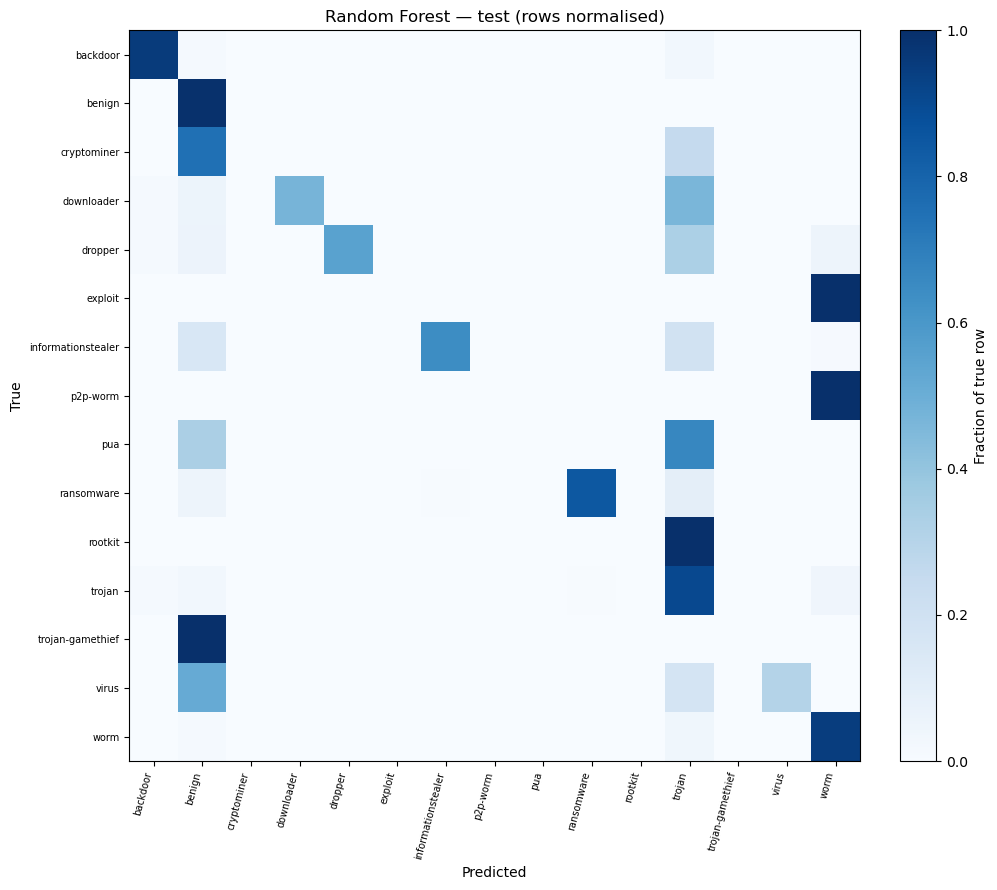

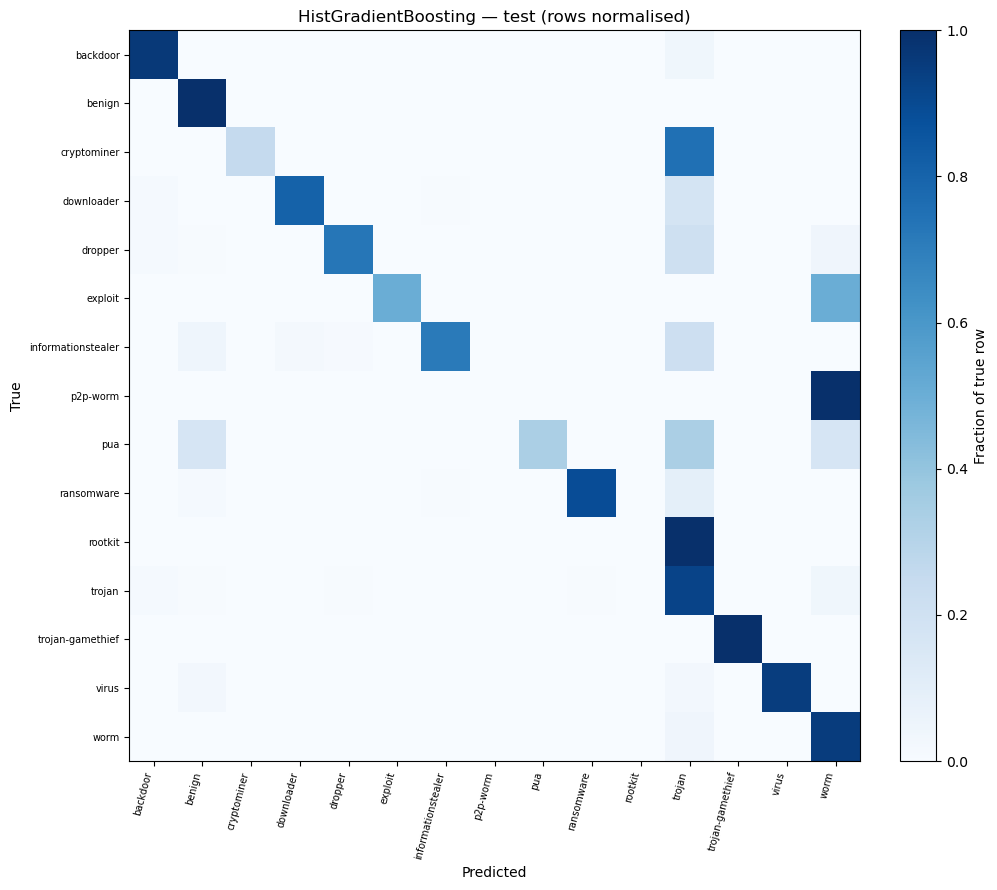

In [18]:
def plot_confusion_row_normalised(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_names_list: list[str],
    title: str,
    save_path: Path,
) -> None:
    lab_idx = np.arange(len(class_names_list))
    cm = confusion_matrix(y_true, y_pred, labels=lab_idx)
    row_sums = cm.sum(axis=1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0.0, vmax=1.0)
    ax.set_title(title)
    n = len(class_names_list)
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(class_names_list, rotation=75, ha="right", fontsize=7)
    ax.set_yticklabels(class_names_list, fontsize=7)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Fraction of true row")
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.show()


plot_confusion_row_normalised(
    y_test,
    rf_test_pred,
    class_names,
    "Random Forest — test (rows normalised)",
    Path("artifacts/cm_rf_test.png"),
)
plot_confusion_row_normalised(
    y_test,
    hgb_test_pred,
    class_names,
    "HistGradientBoosting — test (rows normalised)",
    Path("artifacts/cm_hgb_test.png"),
)

## 11. Side-by-side summary (test set)


In [19]:
summary = pd.DataFrame(
    {
        "Model": ["Random Forest", "HistGradientBoosting"],
        "Test accuracy": [rf_test_acc, hgb_test_acc],
        "Train accuracy": [rf_train_acc, hgb_train_acc],
    }
)
print(summary.to_string(index=False))

compare = pd.DataFrame(
    {
        "class": class_names,
        "RF_TPR": rf_test_df["TPR (recall)"].values,
        "RF_FPR": rf_test_df["FPR"].values,
        "HGB_TPR": hgb_test_df["TPR (recall)"].values,
        "HGB_FPR": hgb_test_df["FPR"].values,
    }
)
print("\nPer-class TPR/FPR on test:")
print(compare.to_string(index=False))

out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)
summary.to_csv(out_dir / "test_summary.csv", index=False)
compare.to_csv(out_dir / "per_class_metrics_test.csv", index=False)
joblib.dump(rf_model, out_dir / "random_forest.joblib")
joblib.dump(hgb_model, out_dir / "hist_gradient_boosting.joblib")
joblib.dump(le, out_dir / "label_encoder.joblib")
joblib.dump(imputer, out_dir / "median_imputer.joblib")
joblib.dump(variance_selector, out_dir / "variance_threshold.joblib")

with open(out_dir / "best_params.json", "w", encoding="utf-8") as f:
    json.dump(
        {"random_forest": rf_search.best_params_, "hist_gradient_boosting": hgb_search.best_params_},
        f,
        indent=2,
        default=str,
    )

print("\nSaved artifacts under ./artifacts/")


               Model  Test accuracy  Train accuracy
       Random Forest       0.957303        0.959097
HistGradientBoosting       0.968758        0.978586

Per-class TPR/FPR on test:
             class   RF_TPR   RF_FPR  HGB_TPR  HGB_FPR
          backdoor 0.956344 0.003934 0.961119 0.003894
            benign 0.996046 0.027140 0.997926 0.005934
       cryptominer 0.000000 0.000000 0.250000 0.000000
        downloader 0.470874 0.000450 0.805825 0.000750
           dropper 0.552448 0.000561 0.727273 0.001383
           exploit 0.000000 0.000000 0.500000 0.000000
informationstealer 0.644444 0.000187 0.711111 0.000373
          p2p-worm 0.000000 0.000000 0.000000 0.000037
               pua 0.000000 0.000000 0.333333 0.000000
        ransomware 0.847561 0.001123 0.890244 0.001123
           rootkit 0.000000 0.000000 0.000000 0.000000
            trojan 0.904587 0.019720 0.924103 0.015652
  trojan-gamethief 0.000000 0.000000 1.000000 0.000000
             virus 0.307692 0.000000 0.948718 

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

## 12. Notes for the PDF report

Copy the printed metrics and tables into your report, and add:

1. **Team roles** — who did data prep, modelling, writing.
2. **Algorithms (≈3 marks)** — turn §7 bullets into cited prose; contrast bagging vs boosting, compute trade-offs, cite malware ML / tabular ML literature.
3. **Preprocessing (≈3 marks)** — row alignment with npz; benign vs malware category merge on SHA-256; median imputation + variance filtering fit **only on train**; rationale for **no** global scaling with tree models; imbalance handling via `class_weight`.
4. **Train/test** — stratified `train_test_split` with `test_size=0.2`, `random_state=42`; held-out test used **once** for final metrics.
5. **Hyperparameters** — `RandomizedSearchCV` with `scoring='f1_macro'` on a stratified subsample (`TUNE_SUBSAMPLE_FRACTION`); inner CV is **`StratifiedKFold` with 3 folds when every class has ≥3 tuning rows**, else **2 folds**, else **`StratifiedShuffleSplit(5)`** if a class is still too small (document which ran). **HistGradientBoosting:** `max_bins`, optional **`HGB_FIT_TRAIN_ROWS`** for `.fit`, tighter `max_depth`/`max_iter` grid, **`early_stopping=False`**. **Random Forest:** `max_samples`, `max_leaf_nodes`, **`RF_FIT_TRAIN_ROWS`**. Train/test **metrics** use full splits for both.
6. **Evaluation** — overall accuracy; define multiclass TPR/FPR (OvR); discuss macro vs weighted F1 if useful; **comparison** of both algorithms on accuracy and rare-class TPR/FPR.
7. **Presentation** — clear figures/tables, grammar, and figure captions; match rubric’s “well-organised, readable”. Include §10 confusion-matrix PNGs (`cm_rf_test.png`, `cm_hgb_test.png`) with captions explaining row normalisation.

Preprocessors, models, and confusion-matrix images are saved under `artifacts/` for reproducibility.
